# Занятие 7: Анализ текстов (Natural Language Processing, NLP)

> Сегодня мы узнаем, как компьютеры “понимают” текст.  
> Мы разберём, что такое токенизация, векторизация и как применить машинное обучение для анализа отзывов.

## Что такое NLP?

**NLP (Natural Language Processing)** — обработка естественного языка.  
Это область искусственного интеллекта, которая позволяет машинам:
- читать текст,
- извлекать смысл,
- классифицировать по настроению или теме,
- генерировать новые тексты.

Примеры:
- Google Translate, ChatGPT, Siri  
- анализ отзывов на сайтах (определение "позитивный / негативный")  
- фильтрация спама в почте  
- автоподписи к фото и видео

## Почему текст сложнее, чем числа?

Компьютер не умеет понимать слова напрямую.  
Он работает только с числами, а текст — это **неструктурированные данные**.  

Например:
| Текст | Что “видит” человек | Что “видит” компьютер |
|:------|:---------------------|:----------------------|
| “Отличный фильм!” | Положительная эмоция | `[12, 340, 56, 2]` |
| “Ужасный сюжет” | Отрицательная эмоция | `[89, 17]` |

Чтобы модель могла анализировать текст, его нужно:
1. **Разбить** на слова (токенизация)  
2. **Очистить** от лишнего (стоп-слова, пунктуация)  
3. **Преобразовать** в числовые векторы (векторизация)

## Шаг 1. Токенизация

> **Токенизация** — это процесс разбиения текста на отдельные слова (токены).

Пример:
"Этот фильм просто невероятный!"
→ ["этот", "фильм", "просто", "невероятный"]


Это основа всего анализа — каждое слово становится отдельным элементом данных.

## Шаг 2. Очистка текста

Тексты часто содержат "мусор": символы, цифры, HTML-теги, эмодзи.  
Также многие слова не несут смысла — **стоп-слова** ("и", "но", "в", "на", "а").

Обычно чистка включает:
- удаление пунктуации и лишних символов  
- приведение к нижнему регистру  
- удаление стоп-слов  
- при необходимости — **лемматизацию** (приведение слова к основе: "играл" → "игра")

Пример:
"Я люблю этот фильм!!!" → "любить фильм"

## Шаг 3. Превращаем слова в числа — Векторизация

После очистки текста нужно превратить слова в числа.  
Есть несколько способов:

1️. **Bag of Words (BoW)** — считаем, сколько раз каждое слово встречается.  
2️. **TF-IDF** — измеряем важность слов относительно всего набора текстов.  
3️. **Word Embeddings** — обучаем вектора, где похожие слова близки в пространстве.

![Nlp pipeline](https://images.prismic.io/turing/65980b21531ac2845a272614_Natural_language_processing_pipeline_e3608ff95c.webp?auto=format,compress)

## Bag of Words

> Каждый текст превращается в вектор длиной равной числу слов в словаре.

Если словарь = {“кот”, “собака”, “хороший”, “плохой”},  
то:

"Хороший кот" → [1, 0, 1, 0]
"Плохая собака" → [0, 1, 0, 1]


Плюсы: просто и наглядно.  
Минусы: не учитывает порядок слов и контекст.


![Bag of Words](https://i.postimg.cc/pLvhy7zs/basicbow.png)
![Bag of Words](https://substack-post-media.s3.amazonaws.com/public/images/7ceec447-d955-4868-8a1a-25ffb689a41b_1275x848.png)

## TF-IDF

**TF-IDF (Term Frequency – Inverse Document Frequency)** показывает, насколько слово важно для конкретного текста.

- **TF** — как часто слово встречается в тексте  
- **IDF** — насколько редко оно встречается в других текстах  

Идея:  
если слово часто встречается во всех текстах (“the”, “и”), оно **не важно**.  
если встречается редко, но только в одном классе — оно **важное**.

TF-IDF помогает выделить ключевые слова:
> В отзывах о фильмах слово “masterpiece” часто встречается только в положительных — значит, оно информативное.


![TF-IDF](https://cdn-media-1.freecodecamp.org/images/1*q3qYevXqQOjJf6Pwdlx8Mw.png)

## Шаг 4. Классификация текстов

После того как текст стал числовым вектором — мы можем применить стандартные модели машинного обучения:

- **Logistic Regression**  
- **Naive Bayes**  
- **SVM (Support Vector Machine)**  
- **Random Forest**

Цель — предсказать категорию:  
положительный / отрицательный отзыв, тема письма, автор текста и т.д.


## Метрики оценки качества

| Метрика | Что показывает |
|----------|----------------|
| **Accuracy** | доля правильно классифицированных текстов |
| **Precision** | насколько предсказанные “положительные” действительно положительные |
| **Recall** | насколько хорошо модель находит все положительные тексты |
| **F1-score** | среднее между precision и recall |

Для визуализации используют **confusion matrix** — матрицу ошибок, которая показывает, где именно модель путается.

## Пример из жизни: анализ отзывов

Допустим, у нас есть отзывы:
- “Обожаю этот фильм!”  
- “Отвратительная актёрская игра.”  
- “Неплохой сюжет, но скучный финал.”

Модель должна определить настроение:
| Отзыв | Класс |
|-------|-------|
| “Обожаю этот фильм!” | 😊 Позитив |
| “Отвратительная актёрская игра.” | 😠 Негатив |
| “Неплохой сюжет, но скучный финал.” | 😐 Нейтральный |

## Визуализация текстов: облако слов

> Облако слов показывает, какие слова встречаются чаще всего.

Часто строят два облака:
- для **позитивных отзывов** — “awesome”, “love”, “great”  
- для **негативных отзывов** — “bad”, “boring”, “waste”

Это отличный способ наглядно увидеть, что отличает классы.

![Пример облака слов](https://drupalhosting.ru/sites/drupalhosting.ru/files/node_images/itp_word_cloud.png)

## Итоги

- Текст нужно очистить и токенизировать.  
- Каждое слово превращается в числовое представление (BoW или TF-IDF).  
- С помощью ML можно определить настроение, тему или категорию текста.  
- NLP — это фундамент для чат-ботов, переводчиков и рекомендательных систем.

# Практическая часть

## Часть 1. Подготовка текста — от слов к числам

### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

### Предобработка текста: токенизация и лемматизация

In [ ]:
import re
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemm = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z ]', '', text) # только буквы и пробелы
    tokens = nltk.word_tokenize(text)
    tokens = [lemm.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)


[nltk_data] Downloading package punkt to /home/danila/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/danila/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/danila/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/danila/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /home/danila/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
print(clean_text("I loved this movie!!! It was amazing and funny :)"))

loved movie amazing funny


### Датасет: отзывы о фильмах (мини IMDb)

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
data = pd.read_csv(url)

# Переименовываем колонки
data = data.rename(columns={'review': 'text', 'sentiment': 'label'})

# Приводим метки в числовой формат
data['label'] = data['label'].map({'positive': 1, 'negative': 0})

# Берём небольшой сбалансированный сэмпл
data = data.sample(5000, random_state=42)

# Чистим текст
data['clean'] = data['text'].apply(clean_text)

data.head()

,text,label,clean
33553,I really liked this Summerslam due to the look...,1,really liked summerslam due look arena curtain...
9427,Not many television shows appeal to quite as m...,1,many television show appeal quite many differe...
199,The film quickly gets to a major chase scene w...,0,film quickly get major chase scene ever increa...
12447,Jane Austen would definitely approve of this o...,1,jane austen would definitely approve onebr br ...
39489,Expectations were somewhat high for me when I ...,0,expectation somewhat high went see movie thoug...


### Токенизация, лемматизация и чистка

In [7]:
print("До:", data['text'].iloc[2])
print("После:", data['clean'].iloc[2])

До: The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would have been beaten to pulp by Seagal's driving, but that probably would have ended the whole premise for the movie.<br /><br />It seems like they decided to make all kinds of changes in the movie plot, so just plan to enjoy the action, and do not expect a coherent plot. Turn any sense of logic you may have, it will reduce your chance of getting a headache.<br /><br />I does give me some hope that Steven Seagal is trying to move back towards the type of characters he portrayed in his more popular movies.
После: film quickly get major chase scene ever increasing destruction first really bad thing guy hijacking steven seagal would beaten pulp seagals driving probably would ended whole premise moviebr br seems like decided make kind change movie plot plan enjoy action expect coherent plot turn sense logic may reduce chance getting headachebr b

> Мы перевели текст в чистый, понятный вид: убрали шум, свели слова к основе, выкинули “и”, “в”, “на”.
> Теперь можно превратить текст в числа — ведь нейросети и ML видят только числа.

## Часть 2. Векторизация текста

In [8]:
bow = CountVectorizer(max_features=3000)
X_bow = bow.fit_transform(data['clean'])
y = data['label']

In [9]:
print("Размерность:", X_bow.shape)

Размерность: (5000, 3000)


### Пример, как это выглядит

In [10]:
bow_df = pd.DataFrame(X_bow.toarray(), columns=bow.get_feature_names_out())
bow_df.head(10)

,abandoned,ability,able,absolute,absolutely,absurd,abuse,academy,accent,accept,...,york,youd,youll,young,younger,youre,youth,youve,zero,zombie
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


> Каждая колонка — это слово, каждая строка — отзыв.
> Если слово встретилось — ставим 1, если нет — 0.
> Простая идея, но не учитывает порядок слов (“не плохой” vs “плохой”).

### TF-IDF — “вес” слова в тексте

In [11]:
tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(data['clean'])

In [12]:
print("Размерность TF-IDF:", X_tfidf.shape)

Размерность TF-IDF: (5000, 3000)


> TF-IDF показывает, насколько слово “уникально” для данного текста.
> Частые слова (например, “movie”, “the”) получают низкий вес,редкие и значимые — высокий.

### Классификация TF-IDF + Logistic Regression

              precision    recall  f1-score   support

           0       0.87      0.80      0.83       506
           1       0.81      0.87      0.84       494

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



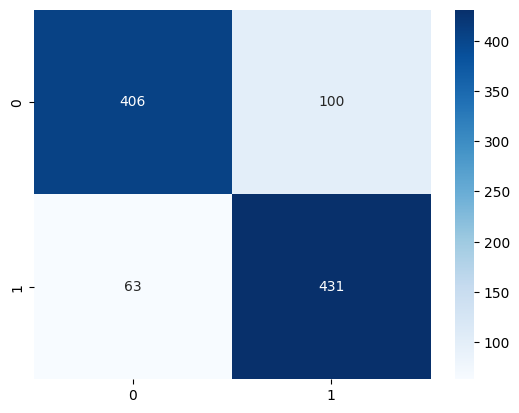

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

model_lr = LogisticRegression(max_iter=200)
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

## Часть 3. Нейросети в NLP

### **Нейросети для текстов: RNN и LSTM**

Когда мы работаем с текстом, порядок слов имеет значение.

**Пример:**
> “Фильм не плохой”  
> “Фильм плохой”  

В классических моделях (Bag of Words, TF-IDF) — это **одинаковый набор слов**.  
Но по смыслу — противоположные предложения.

Чтобы учитывать последовательность слов, придумали **рекуррентные нейронные сети (RNN)**.


#### **RNN** (Recurrent Neural Network) — рекуррентные сети

> Идея: сеть читает текст “по одному слову за раз”,  
> запоминает контекст, и передает его дальше, шаг за шагом.

Пример: предложение “I love this movie”

| Шаг | Вход | Что “помнит” сеть | Выход |
|------|------|--------------------|--------|
| 1 | I | — | скрытое состояние h₁ |
| 2 | love | h₁ → h₂ | “Я люблю” |
| 3 | this | h₂ → h₃ | “Я люблю это” |
| 4 | movie | h₃ → h₄ | “Я люблю этот фильм” |

Каждое новое слово обновляет внутреннюю память сети (hidden state).  
RNN обучается понимать, **что было раньше**.

Это уже больше похоже на то, как читает человек.

#### Проблема классических RNN — "затухание градиента"

Когда предложение длинное (10+ слов), RNN теряет контекст из начала.

> Пример:
> “Фильм, который я посмотрел вчера, был не просто хороший — он был **потрясающий**.”

❌ Простая RNN к слову “потрясающий” уже “забыла”, о каком фильме шла речь.  
Градиенты ошибки “забывают”, что происходило на ранних шагах обучения.

Это называется **vanishing gradient problem**.


#### Решение — **LSTM** (Long Short-Term Memory)

> LSTM — это особый тип RNN, который умеет “запоминать надолго”.

В отличие от обычной RNN, LSTM содержит **внутреннюю ячейку памяти (cell state)**,  
которая передаётся вдоль всей последовательности и обновляется через **входные ворота** (gates).

У LSTM есть три “вратаря”:

| Ворота | Назначение |
|:-------|:------------|
| Forget gate | решает, что забыть из предыдущего состояния |
| Input gate | решает, что добавить из нового слова |
| Output gate | решает, что вывести наружу |

Таким образом, LSTM может:
- помнить контекст фразы “не плохой”,
- игнорировать неважные части (“вчера”, “немного”),
- и понимать смысл длинных предложений.

![Структура LSTM](https://avatars.mds.yandex.net/get-lpc/9736426/50cd10bd-3e8a-4a42-b90b-5a0c580668ae/width_1280_q80)

#### Сравнение RNN и LSTM

| Характеристика | RNN | LSTM |
|-----------------|-----|------|
| Запоминает контекст | На коротких отрезках | На длинных отрезках |
| Проблема затухания градиента | Да | Нет |
| Кол-во параметров | Меньше | Больше |
| Использование | Простые задачи | Реальные NLP-задачи |


#### А чем RNN отличается от CNN?

Хотя CNN тоже может работать с текстами (например, 1D-свёртки), у них **разные цели**:

| Особенность | CNN | RNN / LSTM |
|--------------|-----|------------|
| Как обрабатывает данные | Параллельно, “видит локальные паттерны” | Последовательно, “читает по словам” |
| Основная идея | Фильтры → выделяют признаки | Память → учитывает контекст |
| Лучше для | Изображений, коротких фраз | Текста, речи, временных рядов |
| Учитывает порядок слов | Частично | Да ✅ |

Пример:
- CNN может хорошо “поймать” фразы вроде “очень хороший”,  
- но не понимает, если “очень” и “хороший” разделены пятью словами.  
- LSTM учитывает это, потому что “помнит”, что было раньше.

![CNN vs RNN](https://media.geeksforgeeks.org/wp-content/uploads/20250729140213472401/FNN-vs-RNN.webp)

#### Почему LSTM — это революция для NLP

Благодаря LSTM стало возможным:
- машинный перевод (Google Translate);
- автогенерация текста (предсказание следующего слова);
- анализ длинных отзывов, диалогов и описаний;
- речевые модели (распознавание речи).

LSTM стал мостом между классическим ML и современными моделями Transformer (BERT, GPT).


#### Пример: как работает LSTM на уровне слов

> Предложение: “The movie was not bad at all”

| Слово | Контекст | “Память” LSTM | Оценка |
|:------|:----------|:---------------|:--------|
| The | — | пусто | — |
| movie | нейтрально | фильм | 0.5 |
| was | нейтрально | фильм был | 0.5 |
| not | отрицание | фильм был НЕ | — |
| bad | меняет смысл | фильм был НЕ-плохой | 😐 |
| at all | усиливает | “совсем не плохой” | 😊 |

LSTM запоминает “not” и применяет его к слову “bad”, поэтому правильно понимает, что фраза **положительная**.

#### От LSTM к современным NLP-моделям

- RNN → умеет читать текст последовательно.  
- LSTM → умеет помнить контекст.  
- BiLSTM (двунаправленная) → читает слева направо и справа налево.  
- GRU → упрощённый вариант LSTM, быстрее обучается.  
- Transformers → заменили рекурренцию вниманием (**Attention**).

LSTM и GRU — это последний шаг перед эпохой BERT и GPT.

![Эволюция NLP-моделей](https://i0.wp.com/jasonroell.com/wp-content/uploads/2024/04/RNNs-1.png?ssl=1)

#### Итог по RNN / LSTM

| Модель | Что делает | Где применяется |
|--------|-------------|-----------------|
| RNN | Читает последовательность шаг за шагом | Простые последовательности |
| LSTM | Помнит контекст, фильтрует важное | Тексты, речь, временные ряды |
| GRU | Упрощённый вариант LSTM | Быстрые модели |
| CNN | Видит паттерны, но не последовательность | Картинки, короткие тексты |

После TF-IDF и классических моделей, LSTM — логичный шаг к “понимающему” ИИ.


### Подготовка данных для LSTM

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(data['clean'])
X_seq = tokenizer.texts_to_sequences(data['clean'])
X_pad = pad_sequences(X_seq, maxlen=40, padding='post')

X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

### Модель LSTM

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm = Sequential([
    Embedding(10000, 64, input_length=40),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Обучение модели

In [42]:
history = model_lstm.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5233 - loss: 0.6924 - val_accuracy: 0.6100 - val_loss: 0.6821
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7702 - loss: 0.6230 - val_accuracy: 0.7625 - val_loss: 0.5157
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8941 - loss: 0.3216 - val_accuracy: 0.7675 - val_loss: 0.5256


### Визуализация обучения

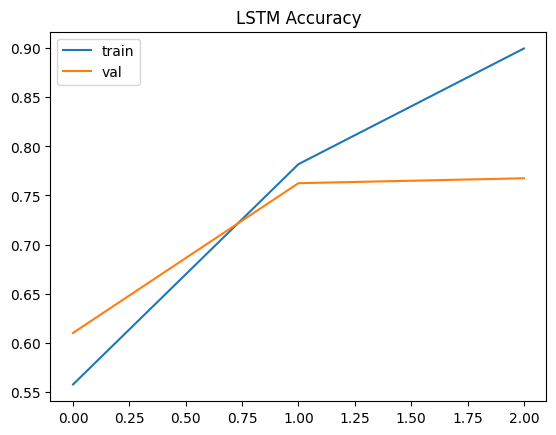

In [43]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("LSTM Accuracy")
plt.show()

### Проверка на примерах

In [44]:
samples = [
    "I absolutely loved this movie, it was great!",
    "This was terrible, I hated every moment",
    "Not bad, but could be better",
    "Amazing story and acting!"
]

for s in samples:
    seq = tokenizer.texts_to_sequences([s])
    pad = pad_sequences(seq, maxlen=40, padding='post')
    pred = model_lstm.predict(pad)[0][0]
    label = "😊 Positive" if pred > 0.5 else "😠 Negative"
    print(f"{s:50s} → {label} ({pred:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
I absolutely loved this movie, it was great!       → 😊 Positive (0.97)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
This was terrible, I hated every moment            → 😠 Negative (0.16)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Not bad, but could be better                       → 😠 Negative (0.03)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Amazing story and acting!                          → 😊 Positive (0.93)


### Визуализируем распределение предсказаний

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


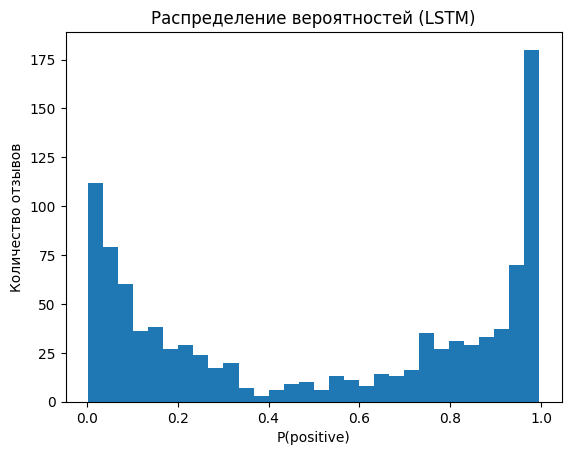

In [45]:
preds = model_lstm.predict(X_test[:1000])
plt.hist(preds, bins=30)
plt.title("Распределение вероятностей (LSTM)")
plt.xlabel("P(positive)")
plt.ylabel("Количество отзывов")
plt.show()


> Большинство отзывов уверенно классифицированы — это значит, что модель уверена в своих решениях.
> Если гистограмма смещена в одну сторону — можно дообучить модель.

### Сравнение моделей

| Модель       | Что использует          | Учитывает порядок слов | Тип модели            |
| ------------ | ----------------------- | ---------------------- | --------------------- |
| Bag of Words | частоты слов            | ❌                      | классика (LogReg, NB) |
| TF-IDF       | важность слов           | ❌                      | классика              |
| LSTM         | последовательность слов | ✅                      | нейросеть             |


### Резюме

- TF-IDF просто считает слова, а LSTM читает текст как человек

- RNN — как память, которая обновляется при каждом слове

- LSTM может помнить слова, которые были в начале предложения

- Современные модели (GPT, BERT) — это продолжение идей LSTM, но гораздо мощнее

## Домашнее задание

1. Измени maxlen и Embedding размер, сравни результаты.

2. Построй графики loss/accuracy на более длинном обучении (epochs=10).

3. Замени LSTM на GRU:

```python
from tensorflow.keras.layers import GRU
model = Sequential([
    Embedding(vocab_size, 128, input_length=maxlen),
    GRU(128),
    Dense(1, activation='sigmoid')
])
```